In [25]:
!git clone https://github.com/aliakseizvertouski/bet_analyse

fatal: destination path 'bet_analyse' already exists and is not an empty directory.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Stage-level

In [27]:
bet = pd.read_csv('/content/bet_analyse/bets.csv', sep="|")
bet = bet.copy()

bet["accept_time"] = pd.to_datetime(bet["accept_time"])
bet["create_time"] = pd.to_datetime(bet["create_time"])
bet["settlement_time"] = pd.to_datetime(bet["settlement_time"])
bet.head()

,bet_id,player_id,accept_time,create_time,settlement_time,result,amount,payout,profit,bet_type,...,accepted_bet_odd,item_result,event_stage,accepted_odd,item_amount,item_payout,item_profit,event_id,is_free_bet,settlement_status
0,4580f660-d16a-4ad6-8837-47574564a37f,cf928a91-a17d-42cd-8924-7c3fccd54acb,2022-03-14 00:00:00.165,2022-03-13 23:59:54.503,2022-03-14 00:21:59.745,Return,1.00,1.00,0.00,Ordinar,...,7.50,Return,Live,7.50,1.00,1.00,0.00,c3929913-1eef-4703-ada2-fe08fd47c79d,False,Settled
1,7435c382-e448-4c0b-8b56-a9e547ca6605,cf928a91-a17d-42cd-8924-7c3fccd54acb,2022-03-14 00:00:36.819,2022-03-14 00:00:31.160,2022-03-14 00:10:16.243,Win,0.95,2.48,-1.53,Ordinar,...,2.62,Win,Live,2.62,0.95,2.48,-1.53,c3929913-1eef-4703-ada2-fe08fd47c79d,False,Settled
2,ae36ffa2-0bb5-4bd7-8cf6-e15416ae4fc7,f1866879-4b0f-4a58-aaa9-24e6224cb139,2022-03-14 00:01:07.941,2022-03-14 00:01:07.743,2022-03-14 04:37:24.291,Win,3.51,7.51,-4.00,Ordinar,...,2.14,Win,Prematch,2.14,3.51,7.51,-4.00,7b6aaa15-3b2e-4977-8b1a-59472eeb0817,False,Settled
3,57009dc1-60c5-46f7-acb5-1a45a19983b7,e5efcd9c-aa46-48a1-be0e-9e9f9aa37b53,2022-03-14 00:01:27.927,2022-03-14 00:01:27.927,NaT,NaN,1.00,NaN,NaN,Express,...,0.00,NaN,NaN,0.00,0.00,NaN,NaN,0b912707-3b87-4ec3-886c-2b0f96303977,False,Rejected
4,57009dc1-60c5-46f7-acb5-1a45a19983b7,e5efcd9c-aa46-48a1-be0e-9e9f9aa37b53,2022-03-14 00:01:27.927,2022-03-14 00:01:27.927,NaT,NaN,1.00,NaN,NaN,Express,...,0.00,NaN,NaN,0.00,0.00,NaN,NaN,c3929913-1eef-4703-ada2-fe08fd47c79d,False,Rejected


### Колонки

**Идентификаторы**
* bet_id: Уникальный номер ставки.

* player_id: Уникальный идентификатор игрока.

* event_id: Идентификатор спортивного события (матча).

**Временные метки**
* create_time: Время, когда игрок нажал кнопку «Сделать ставку».

* accept_time: Время, когда ставка была официально принята системой (после проверок).

* settlement_time: Время расчета ставки (когда результат игры занесен в базу и выплачены деньги).

**Финансовые данные**
* amount: Сумма ставки (тело ставки).

* payout: Сумма выплаты игроку (0, если проигрыш; amount * odd, если выигрыш).

* profit: Чистый финансовый результат для игрока (payout - amount).

* accepted_bet_odd: Итоговый коэффициент всей ставки.

* accepted_odd: Коэффициент конкретного исхода (актуально для экспрессов).

* item_amount / item_payout / item_profit: Детализация финансовых показателей для конкретного исхода внутри купона.

**Статусы и категории**
* result: Результат ставки (Win — победа, Lose — проигрыш, Return — возврат, Cashout — досрочный выкуп).

* item_result: Результат конкретного события внутри ставки.

* bet_type: Тип ставки (например, Ordinar — ординар или Express — экспресс).

* bet_size: Категория размера ставки (вероятно, внутренняя сегментация).

* event_stage: Фаза события в момент ставки (Live — по ходу матча, Prematch — до начала).

* is_free_bet: Флаг (True/False), была ли ставка сделана на бонусные деньги (фрибет).

* settlement_status: Статус обработки (Settled — рассчитана, Rejected — отклонена).

# Core-level

### Игроки

In [28]:
players = bet.groupby("player_id").agg(
    bets=("bet_id", "count"),
    turnover=("amount", "sum"),
    profit=("profit", "sum"),
    payout=("payout", "sum"),
    avg_bet=("amount", "mean"),
    avg_odd=("accepted_bet_odd", "mean"),
    std_profit=("profit", "std"),
    free_bets=("is_free_bet", lambda x: (x == 1).sum()),
).reset_index()

players.head()

,player_id,bets,turnover,profit,payout,avg_bet,avg_odd,std_profit,free_bets
0,0038a99b-bdcd-47d7-93ef-812c54804993,28,505.23,-136.86,622.09,18.043929,1.696179,11.432045,0
1,00a8f5ce-3fb0-432b-94df-76ff2693951f,11,26.00,26.00,0.00,2.363636,13.122818,0.504525,0
2,00e94ea9-fa45-4f2f-81db-839caee89f39,108,53.83,17.58,32.57,0.498426,3.425092,0.718604,0
3,01354ecc-625b-477a-8fbf-87ff5e3da1a2,185,614.66,67.94,106.72,3.322486,8.554269,1.059728,0
4,018f4bde-9906-412e-abdb-b9a4fbf320b8,12,395.50,184.50,181.00,32.958333,3.019167,33.846243,0


### Поведение ставок

In [29]:
result_stats = bet.groupby("result").agg(
    count=("bet_id", "count"),
    turnover=("amount", "sum"),
    profit=("profit", "sum")
).reset_index()

result_stats["percent"] = result_stats["count"] / result_stats["count"].sum() * 100

result_stats.head()

,result,count,turnover,profit,percent
0,Cashout,1285,21892.07,1173.97,1.598676
1,Lose,60110,353419.52,353264.52,74.783215
2,Return,713,5783.10,0.00,0.887048
3,TechnicalReturn,11,505.05,0.00,0.013685
4,Win,18260,207606.87,-276849.67,22.717376


### Игровые сессии

In [30]:
game_stats = bet.groupby("event_id").agg(
    bets=("bet_id", "count"),
    turnover=("amount", "sum"),
    profit=("profit", "sum")
).reset_index()

game_stats.head()

,event_id,bets,turnover,profit
0,0006330b-9987-4284-a7c0-b9a7143fc6c5,5,3.80,1.70
1,000d941c-8cc9-40f8-9af1-0df431783159,24,81.16,-11.06
2,001d12ac-d48e-4b97-a7f7-e99daa224d5f,12,71.15,44.15
3,0024cdb9-25c8-43b7-9748-fdc9c0cec4a4,1,3.00,3.00
4,002acb12-cf57-4768-89b4-aab175820810,22,79.39,62.60


# Расчет показателей

### Основные финансовые показатели за отчетный период

In [31]:
settled_bets = bet[bet['settlement_status'] == 'Settled'].drop_duplicates('bet_id').copy()
settled_bets['payout'] = settled_bets['payout'].fillna(0)

total_turnover = settled_bets['amount'].sum()
total_payout = settled_bets['payout'].sum()
ggr = total_turnover - total_payout
rtp = total_payout / total_turnover

kpi_table = pd.DataFrame([{
    "turnover": total_turnover, #оборот
    "payout": total_payout, #выплаты
    "ggr": ggr, #прибыль букмекера: сколько поставили - сколько выплатили
    "rtp": f"{rtp:.2%}", #процент от ставок вернулся игрокам
    "margin": f"{(1 - rtp):.2%}" #маржа
}])

kpi_table

,turnover,payout,ggr,rtp,margin
0,392407.21,375050.91,17356.3,95.58%,4.42%


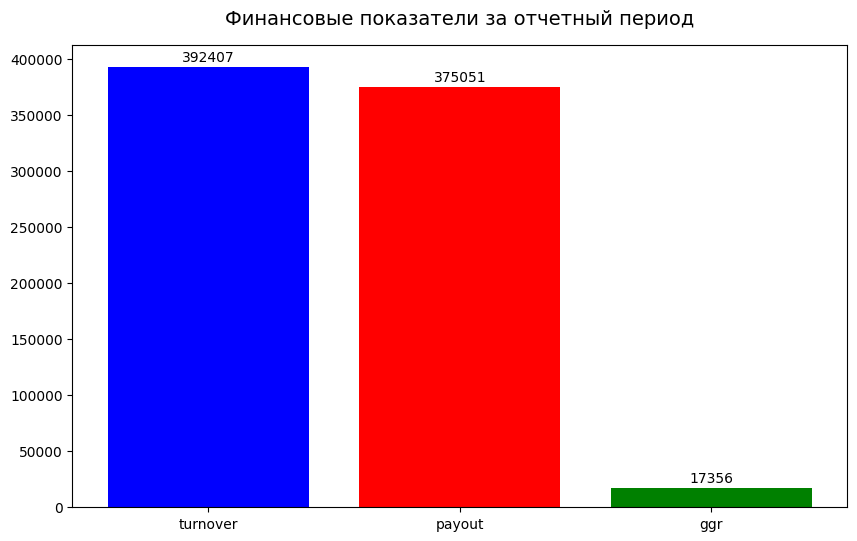

In [32]:
plot_data = kpi_table[['turnover', 'payout', 'ggr']].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(plot_data.index, plot_data.values, color=['blue', 'red', 'green', 'yellow'])

ax.bar_label(bars, padding=2, fmt='%.0f')

ax.set_title('Финансовые показатели за отчетный период', fontsize=14, pad=15)

plt.show()

### Итоги игровых сессий

In [33]:
wins_looses = bet.groupby("result").size().reset_index(name="count")

wins_looses["percent"] = wins_looses["count"] / wins_looses["count"].sum() * 100

wins_looses

,result,count,percent
0,Cashout,1285,1.598676
1,Lose,60110,74.783215
2,Return,713,0.887048
3,TechnicalReturn,11,0.013685
4,Win,18260,22.717376


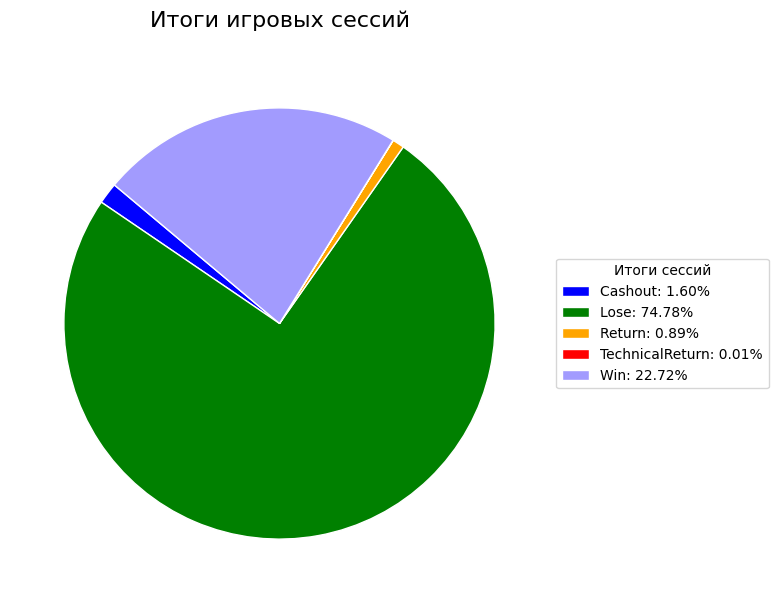

In [34]:
fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')

plt.rcParams['font.family'] = 'sans-serif'

ax.set_title('Итоги игровых сессий', fontsize=16, pad=20)

wedges, _ = ax.pie(
    wins_looses['count'],
    startangle=140,
    colors=['blue', 'green', 'orange', 'red', '#a29bfe'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

legend_labels = [f'{i}: {c:.2f}%' for i, c in zip(wins_looses['result'], wins_looses['percent'])]


ax.legend(
    wedges,
    legend_labels,
    title="Итоги сессий",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.show()

# Анализ времени задержек ставок

In [35]:
bet["accept_delay"] = (bet["accept_time"] - bet["create_time"]).dt.total_seconds()         # время между созданием ставки и её подтверждением (cек)
bet["settlement_delay"] = (bet["settlement_time"] - bet["accept_time"]).dt.total_seconds() # время от принятия ставки до её расчёта (cек)

churn_rate = bet[['player_id', "accept_delay", "settlement_delay"]]
churn_rate.head()

,player_id,accept_delay,settlement_delay
0,cf928a91-a17d-42cd-8924-7c3fccd54acb,5.662,1319.580
1,cf928a91-a17d-42cd-8924-7c3fccd54acb,5.659,579.424
2,f1866879-4b0f-4a58-aaa9-24e6224cb139,0.198,16576.350
3,e5efcd9c-aa46-48a1-be0e-9e9f9aa37b53,0.000,NaN
4,e5efcd9c-aa46-48a1-be0e-9e9f9aa37b53,0.000,NaN


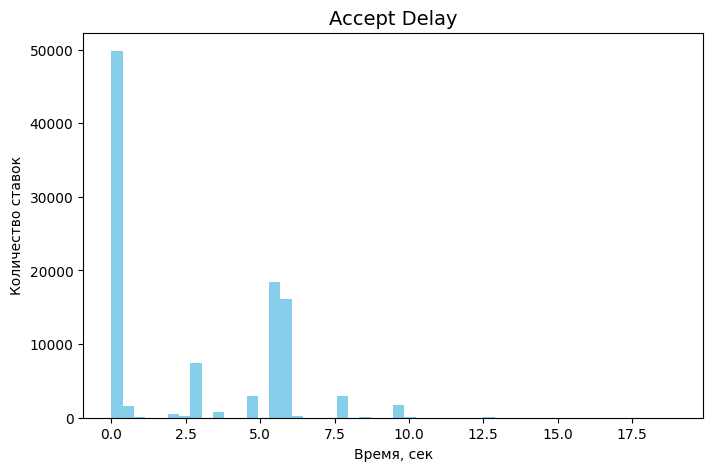

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(bet["accept_delay"], bins=50,  color='skyblue')

ax.set_title('Accept Delay', fontsize=14)
ax.set_xlabel('Время, сек')
ax.set_ylabel('Количество ставок')

plt.show()

задержки есть, но они приемлимые, до 10 сек

In [37]:
accept_delay_stats = pd.DataFrame([{
    "mean_accept_delay": bet["accept_delay"].mean(),
    "min_accept_delay": bet["accept_delay"].min(),
    "max_accept_delay": bet["accept_delay"].max()
}])

accept_delay_stats

,mean_accept_delay,min_accept_delay,max_accept_delay
0,2.754518,0.0,18.942


ого! оказывается что есть какие-то задержки до 18.9 сек

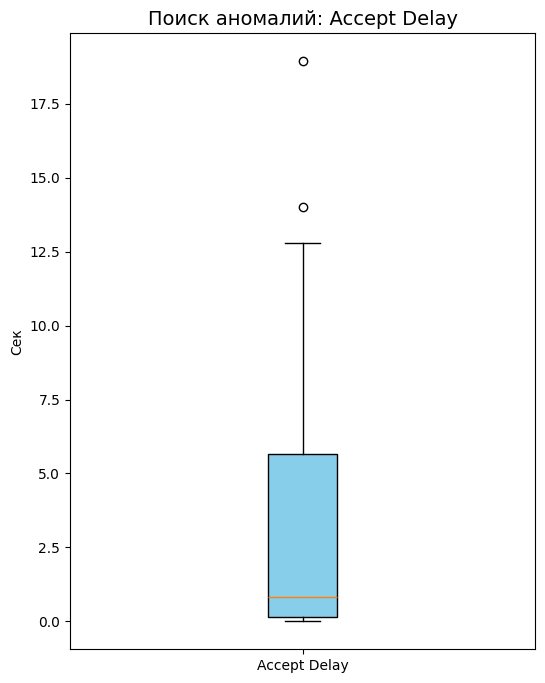

In [38]:
fig, ax = plt.subplots(figsize=(6, 8))

ax.boxplot(bet["accept_delay"],
           tick_labels=['Accept Delay'],
           patch_artist=True,
           boxprops=dict(facecolor='skyblue')
)

ax.set_title('Поиск аномалий: Accept Delay', fontsize=14)
ax.set_ylabel('Сек')

plt.show()

ого. на усах видны аномалии, которых не видно на гистограмме

значительная часть игроков сталкивается с ощутимым ожиданием (до 7 сек), что приемлимо. но есть и аномалии до 19сек!

### влияют ли задержки на отказы от ставкок?

In [39]:
delay_check = bet[
    (bet["accept_delay"] > 10) &
    (bet["result"] == "TechnicalReturn")
][["bet_id", "accept_delay", "result"]]

delay_check.head()

,bet_id,accept_delay,result


задержки есть, но когда они случаются игроки не заканчивают игровую сессию - все ок

#Фриспины - тема?

In [40]:
free_bet_players = (
    bet[['player_id', 'bet_id', 'is_free_bet']]
    .drop_duplicates()
    .groupby(['player_id', 'is_free_bet'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "non_free", True: "free"})
)

free_bet_players = free_bet_players[
    (free_bet_players["non_free"] == 0) &
    (free_bet_players["free"] > 10)
]

free_bet_players

is_free_bet,non_free,free
player_id,,
c02e1329-57f6-42af-a478-216c825a9ddc,0,31
f986aad8-d457-482e-aaee-675a37b70b78,0,14


опа, есть люди, пытающиеся срубить денег с 0 вложений

In [41]:
freeloaders = free_bet_players.reset_index()
freeloaders = freeloaders['player_id'].nunique() / bet['player_id'].nunique() * 100

print (f'итого халявщиков: {freeloaders} %')

итого халявщиков: 0.2544529262086514 %


их кстати очень мало в процентном соотношении в общему числу игроков. перепадает им что-нибудь?

In [42]:
profit_by_player = bet.groupby("player_id")["profit"].sum().reset_index()

freeloaders_profit = free_bet_players.merge(profit_by_player, on="player_id", how="left")
freeloaders_profit

,player_id,non_free,free,profit
0,c02e1329-57f6-42af-a478-216c825a9ddc,0,31,0.0
1,f986aad8-d457-482e-aaee-675a37b70b78,0,14,0.0


неа( не стоит надеяться на фриспины